  FI2026 Öpik B-plane Analysis
  SOI entry epoch        : 2000.98066  yr
  v∞  (hyperbolic excess): 5.8244  km/s
  Hyperbolic eccentricity: 1.000431
  Impact parameter B     : 344.9  km
  Periapsis rP           : 5.1  km  (0.0008 R_E)
  Impact cross-sec radius: 13795.3  km
  B < B_impact?          : True  → IMPACT
  Öpik  ξ                : -240.9  km
  Öpik  ζ                : -246.9  km
  Scaled ξ_SC            : -111.3  km
  Scaled ζ_SC            : -114.0  km
  Linearised impact time : 2000.985426  yr


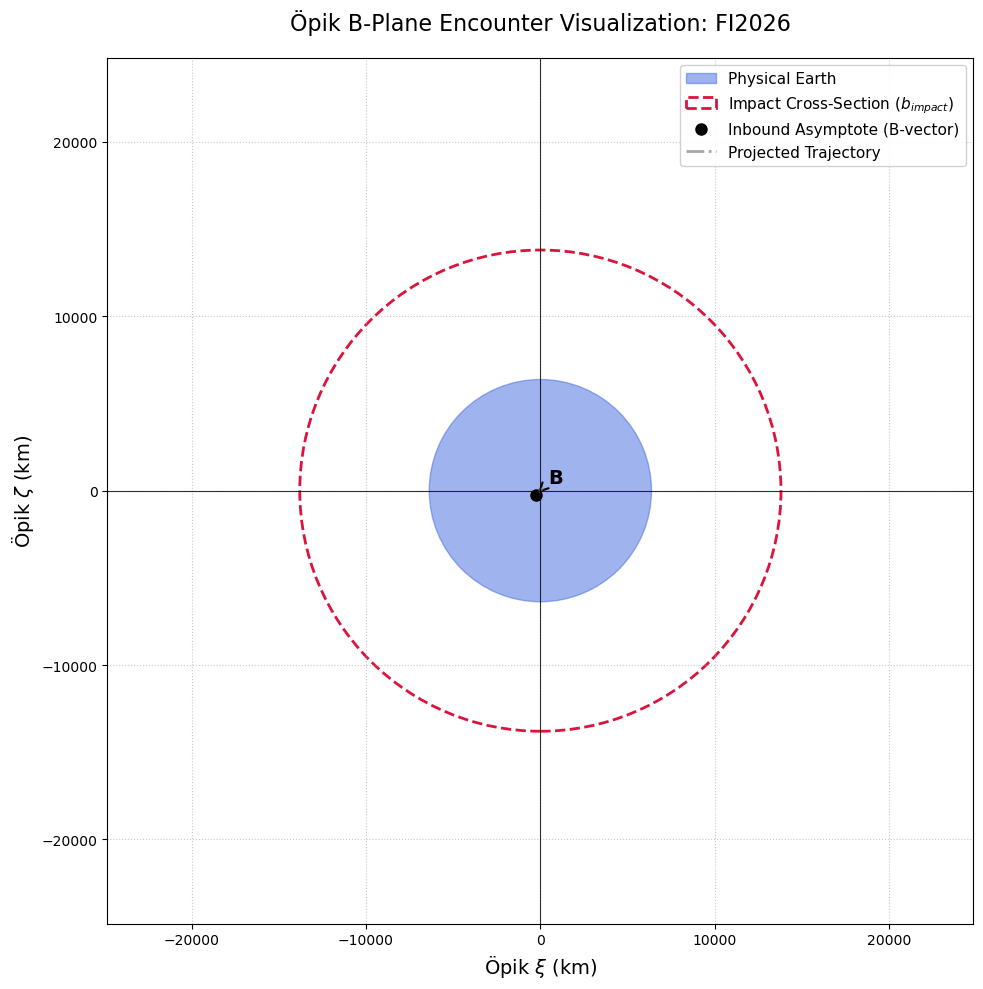

In [ ]:
"""
Öpik B-plane visualization for the FI2026 Earth encounter
==========================================================
Implements the full Farnocchia formulation:
  - Geocentric hyperbolic orbit at SOI entry
  - Inbound asymptote Ŝ from perifocal frame 
  - B vector from angular momentum 
  - Öpik frame (ξ̂, ζ̂) 
  - Impact cross-section 
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyArrowPatch
from matplotlib.gridspec import GridSpec

# ──────────────────────────────────────────────────────────────
# CONSTANTS
# ──────────────────────────────────────────────────────────────
GM_SUN   = 1.32712440018e20
GM_EARTH = 3.986004418e14
AU       = 1.495978707e11
R_EARTH  = 6.371e6
SOI      = 9.24e8

# ──────────────────────────────────────────────────────────────
# ORBITAL ELEMENTS  
# ──────────────────────────────────────────────────────────────
def semi_major(q, e): return q / (1 - e)
def mean_motion(a, GM=GM_SUN): return np.sqrt(GM / a**3)

earth_el  = dict(q=9.78969676e-01*AU, e=1.83889630e-02, i=7.55697209e-05,
                 w=5.34322623, Om=2.63906227, M0=1.88972281)
fi2026_el = dict(q=0.74161536*AU,     e=0.19293483,     i=0.05877868,
                 w=2.22509624,         Om=3.55784498,     M0=3.64624167)

def solve_kepler(M, e, tol=1e-12):
    E = float(M)
    for _ in range(100):
        dE = (M - E + e*np.sin(E)) / (1 - e*np.cos(E))
        E += dE
        if abs(dE) < tol: break
    return E

def state_from_elements(el, t):
    q,e,i,w,Om,M0 = el['q'],el['e'],el['i'],el['w'],el['Om'],el['M0']
    a = semi_major(q, e)
    n = mean_motion(a)
    M = (M0 + n*t) % (2*np.pi)
    E = solve_kepler(M, e)
    nu = 2*np.arctan2(np.sqrt(1+e)*np.sin(E/2), np.sqrt(1-e)*np.cos(E/2))
    p  = a*(1-e**2)
    r  = p/(1+e*np.cos(nu))
    h  = np.sqrt(GM_SUN*p)
    rx_p = r*np.cos(nu); ry_p = r*np.sin(nu)
    vx_p = -GM_SUN/h*np.sin(nu); vy_p = GM_SUN/h*(e+np.cos(nu))
    cO,sO = np.cos(Om),np.sin(Om)
    ci,si = np.cos(i), np.sin(i)
    cw,sw = np.cos(w), np.sin(w)
    Qxx =  cO*cw - sO*sw*ci;  Qxy = -cO*sw - sO*cw*ci
    Qyx =  sO*cw + cO*sw*ci;  Qyy = -sO*sw + cO*cw*ci
    Qzx =  sw*si;              Qzy =  cw*si
    rv = np.array([Qxx*rx_p+Qxy*ry_p, Qyx*rx_p+Qyy*ry_p, Qzx*rx_p+Qzy*ry_p])
    vv = np.array([Qxx*vx_p+Qxy*vy_p, Qyx*vx_p+Qyy*vy_p, Qzx*vx_p+Qzy*vy_p])
    return rv, vv

# ──────────────────────────────────────────────────────────────
# FIND SOI ENTRY 
# ──────────────────────────────────────────────────────────────
# Coarse scan
t_scan = np.arange(0, 400*86400, 3600.0)
pe_all  = np.array([state_from_elements(earth_el,  t)[0] for t in t_scan]).T
pfi_all = np.array([state_from_elements(fi2026_el, t)[0] for t in t_scan]).T
sep_all = np.linalg.norm(pfi_all - pe_all, axis=0)

# Fine scan around first close approach
ca_idx  = int(np.argmin(sep_all))
t_fine  = np.arange(t_scan[ca_idx]-30*86400, t_scan[ca_idx]+30*86400, 60.0)
pe_f    = np.array([state_from_elements(earth_el,  t)[0] for t in t_fine]).T
ve_f    = np.array([state_from_elements(earth_el,  t)[1] for t in t_fine]).T
pfi_f   = np.array([state_from_elements(fi2026_el, t)[0] for t in t_fine]).T
vfi_f   = np.array([state_from_elements(fi2026_el, t)[1] for t in t_fine]).T
sep_f   = np.linalg.norm(pfi_f - pe_f, axis=0)

soi_mask = sep_f < SOI
soi_first = np.argmax(soi_mask)
t_soi  = t_fine[soi_first]

# State at SOI entry
r_e_soi, v_e_soi   = state_from_elements(earth_el,  t_soi)
r_fi_soi, v_fi_soi = state_from_elements(fi2026_el, t_soi)

# Geocentric relative state
r_geo = r_fi_soi - r_e_soi    # position of asteroid relative to Earth [m]
v_geo = v_fi_soi - v_e_soi    # velocity of asteroid relative to Earth [m/s]

# ──────────────────────────────────────────────────────────────
# B-PLANE CONSTRUCTION 
# ──────────────────────────────────────────────────────────────

# --- Geocentric hyperbolic orbit elements ---
r_mag = np.linalg.norm(r_geo)
v_mag = np.linalg.norm(v_geo)

# Specific energy → v∞ 
eps   = 0.5*v_mag**2 - GM_EARTH/r_mag
v_inf = np.sqrt(2*eps)
a_hyp = -GM_EARTH / (2*eps)          # negative (hyperbola)

# Specific angular momentum
h_vec = np.cross(r_geo, v_geo)
h_mag = np.linalg.norm(h_vec)

# Eccentricity vector  (Eq. 3)
e_vec = np.cross(v_geo, h_vec)/GM_EARTH - r_geo/r_mag
e_mag = np.linalg.norm(e_vec)

# Perifocal unit vectors  P̂, Q̂
P_hat = e_vec / e_mag
Q_hat = np.cross(h_vec/h_mag, P_hat)

# Inbound asymptote direction Ŝ 
S_hat = (P_hat/e_mag + np.sqrt(e_mag**2-1)/e_mag * Q_hat)

# B vector 
B_vec = np.cross(S_hat, h_vec) / v_inf
B_mag = np.linalg.norm(B_vec)

# ──────────────────────────────────────────────────────────────
# ÖPIK FRAME
# ──────────────────────────────────────────────────────────────
# Planet's inertial heliocentric velocity at time of mapping
v_pl = v_e_soi  # heliocentric velocity of Earth at SOI-entry epoch

xi_hat  = np.cross(v_pl, S_hat) / np.linalg.norm(np.cross(v_pl, S_hat))  
zeta_hat = -np.cross(S_hat, xi_hat)                                      

# Öpik coordinates (Eq. 38)
xi_B   =  np.dot(B_vec, xi_hat)    # ξ  = B · ξ̂
zeta_B =  np.dot(B_vec, zeta_hat)  # ζ  = B · ζ̂

# ──────────────────────────────────────────────────────────────
# IMPACT CROSS SECTION  (Eq. 14) with gravitational focusing
# ──────────────────────────────────────────────────────────────
B_impact = R_EARTH * np.sqrt(1 + 2*GM_EARTH/(R_EARTH*v_inf**2))

# ──────────────────────────────────────────────────────────────
# SCALED B-PLANE COORDS  
# ──────────────────────────────────────────────────────────────
lam     = np.sqrt(1 + 2*GM_EARTH/(R_EARTH*v_inf**2))
xi_sc   = xi_B   / lam
zeta_sc = zeta_B / lam
B_sc    = B_mag  / lam

# ──────────────────────────────────────────────────────────────
# LINEARIZED TIME OF FLIGHT  tL 
# ──────────────────────────────────────────────────────────────
n_hyp = np.sqrt(-GM_EARTH/a_hyp**3)
# Hyperbolic eccentric anomaly F
sinh_F = np.dot(r_geo, v_geo)*v_inf / (GM_EARTH)
F      = np.arcsinh(sinh_F / e_mag)
tL_offset = (F - e_mag*np.sinh(F) - np.log(e_mag)) / n_hyp  # t_L - t
t_L = t_soi + tL_offset

# ──────────────────────────────────────────────────────────────
# PERIAPSIS via B-plane relation  rP 
# ──────────────────────────────────────────────────────────────
rP = -GM_EARTH/v_inf**2 + np.sqrt((GM_EARTH/v_inf**2)**2 + B_mag**2)

# ──────────────────────────────────────────────────────────────
# HYPERBOLIC TRAJECTORY IN GEOCENTRIC PLANE  for illustration
# ──────────────────────────────────────────────────────────────
# Semi-latus rectum
p_hyp = h_mag**2 / GM_EARTH
nu_arr = np.linspace(-np.arccos(-1/e_mag)*0.97, np.arccos(-1/e_mag)*0.97, 2000)
r_arr  = p_hyp / (1 + e_mag*np.cos(nu_arr))
# In perifocal plane
x_peri = r_arr * np.cos(nu_arr)
y_peri = r_arr * np.sin(nu_arr)

# Rotate to B-plane (ξ, ζ) frame by projecting P̂ and Q̂ onto it
Px_op = np.dot(P_hat, xi_hat);   Py_op = np.dot(P_hat, zeta_hat)
Qx_op = np.dot(Q_hat, xi_hat);   Qy_op = np.dot(Q_hat, zeta_hat)

xi_traj   = x_peri*Px_op + y_peri*Qx_op
zeta_traj = x_peri*Py_op + y_peri*Qy_op

# ──────────────────────────────────────────────────────────────
# PRINT SUMMARY
# ──────────────────────────────────────────────────────────────
yr_soi    = 2000 + t_soi/86400/365.25
yr_impact = 2000 + t_L /86400/365.25

print(f"{'='*55}")
print(f"  FI2026 Öpik B-plane Analysis")
print(f"{'='*55}")
print(f"  SOI entry epoch        : {yr_soi:.5f}  yr")
print(f"  v∞  (hyperbolic excess): {v_inf/1e3:.4f}  km/s")
print(f"  Hyperbolic eccentricity: {e_mag:.6f}")
print(f"  Impact parameter B     : {B_mag/1e3:.1f}  km")
print(f"  Periapsis rP           : {rP/1e3:.1f}  km  ({rP/R_EARTH:.4f} R_E)")
print(f"  Impact cross-sec radius: {B_impact/1e3:.1f}  km")
print(f"  B < B_impact?          : {B_mag < B_impact}  → IMPACT")
print(f"  Öpik  ξ                : {xi_B/1e3:.1f}  km")
print(f"  Öpik  ζ                : {zeta_B/1e3:.1f}  km")
print(f"  Scaled ξ_SC            : {xi_sc/1e3:.1f}  km")
print(f"  Scaled ζ_SC            : {zeta_sc/1e3:.1f}  km")
print(f"  Linearised impact time : {yr_impact:.6f}  yr")
print(f"{'='*55}")

# ──────────────────────────────────────────────────────────────
# ÖPIK B-PLANE VISUALIZATION
# ──────────────────────────────────────────────────────────────
# Convert values to km for standard B-plane visualization
r_earth_km = R_EARTH / 1e3
b_impact_km = B_impact / 1e3
xi_b_km = xi_B / 1e3
zeta_b_km = zeta_B / 1e3

fig, ax = plt.subplots(figsize=(10, 10))

# 1. Plot Physical Earth
earth_patch = patches.Circle((0, 0), r_earth_km, color='royalblue', alpha=0.5, label='Physical Earth')
ax.add_patch(earth_patch)

# 2. Plot Gravitational Capture Cross-Section
impact_patch = patches.Circle((0, 0), b_impact_km, color='crimson', fill=False, 
                              linestyle='--', linewidth=2, 
                              label=r'Impact Cross-Section ($b_{impact}$)')
ax.add_patch(impact_patch)

# 3. Plot the B-vector point (Inbound Asymptote intersection with B-plane)
ax.plot(xi_b_km, zeta_b_km, 'ko', markersize=8, label='Inbound Asymptote (B-vector)')
ax.annotate(r'$\mathbf{B}$', xy=(xi_b_km, zeta_b_km), 
            xytext=(xi_b_km + (b_impact_km*0.05), zeta_b_km + (b_impact_km*0.05)), 
            fontsize=14, fontweight='bold')

# Draw vector arrow from origin to B
arrow = FancyArrowPatch((0, 0), (xi_b_km, zeta_b_km), arrowstyle='->', 
                        color='black', mutation_scale=15, linewidth=1.5)
ax.add_patch(arrow)

# 4. Plot the projected hyperbolic trajectory
# Filter the trajectory points to only show the segment near Earth 
# to prevent the plot limits from blowing out to infinity.
plot_limit = b_impact_km * 1.8
mask = (np.abs(xi_traj) / 1e3 < plot_limit*1.5) & (np.abs(zeta_traj) / 1e3 < plot_limit*1.5)
ax.plot(xi_traj[mask] / 1e3, zeta_traj[mask] / 1e3, 'gray', 
        linestyle='-.', alpha=0.7, linewidth=2, label='Projected Trajectory')

# Formatting and Aesthetics
ax.set_aspect('equal')
ax.set_xlim(-plot_limit, plot_limit)
ax.set_ylim(-plot_limit, plot_limit)

# Axis lines intersecting at origin (Earth Center)
ax.axhline(0, color='black', linewidth=0.8, alpha=0.8)
ax.axvline(0, color='black', linewidth=0.8, alpha=0.8)

ax.grid(True, linestyle=':', alpha=0.7)
ax.set_title('Öpik B-Plane Encounter Visualization: FI2026', fontsize=16, pad=20)
ax.set_xlabel(r'Öpik $\xi$ (km)', fontsize=14)
ax.set_ylabel(r'Öpik $\zeta$ (km)', fontsize=14)

# Legend setup
ax.legend(loc='upper right', fontsize=11, framealpha=0.9)

plt.tight_layout()
plt.show()

  Heliocentric Propagation — Nominal Verification
  SOI entry:  analytic = 358.19 d,  numeric = 358.19 d  (Δ = 0.0 h)
  |B|:  cell-0 = 344.9 km,  helio prop = 344.9 km
  (ξ, ζ): (-240.9, -246.9) vs (-240.9, -246.9) km

────────────────────────────────────────────────────────────
  3. SLOW-PUSH  (heliocentric RSW, epoch → SOI)
────────────────────────────────────────────────────────────

  R-direction: solving... done
    Accel    = 1.5615e-07 m/s²  (sign -)
    Duration = 358.2 days
    ΔV       = 4.832547 m/s  (483.2547 cm/s)
    |B|      = 25484.0 km  (4.00 R_E)
    (ξ, ζ)   = (-1768.6, -25422.6) km

  S-direction: solving... done
    Accel    = 1.8973e-08 m/s²  (sign -)
    Duration = 358.2 days
    ΔV       = 0.587177 m/s  (58.7177 cm/s)
    |B|      = 25484.0 km  (4.00 R_E)
    (ξ, ζ)   = (-1915.1, -25411.9) km

  W-direction: solving... done
    Accel    = 7.1097e-07 m/s²  (sign -)
    Duration = 358.2 days
    ΔV       = 22.003509 m/s  (2200.3509 cm/s)
    |B|      = 25484.0 km 

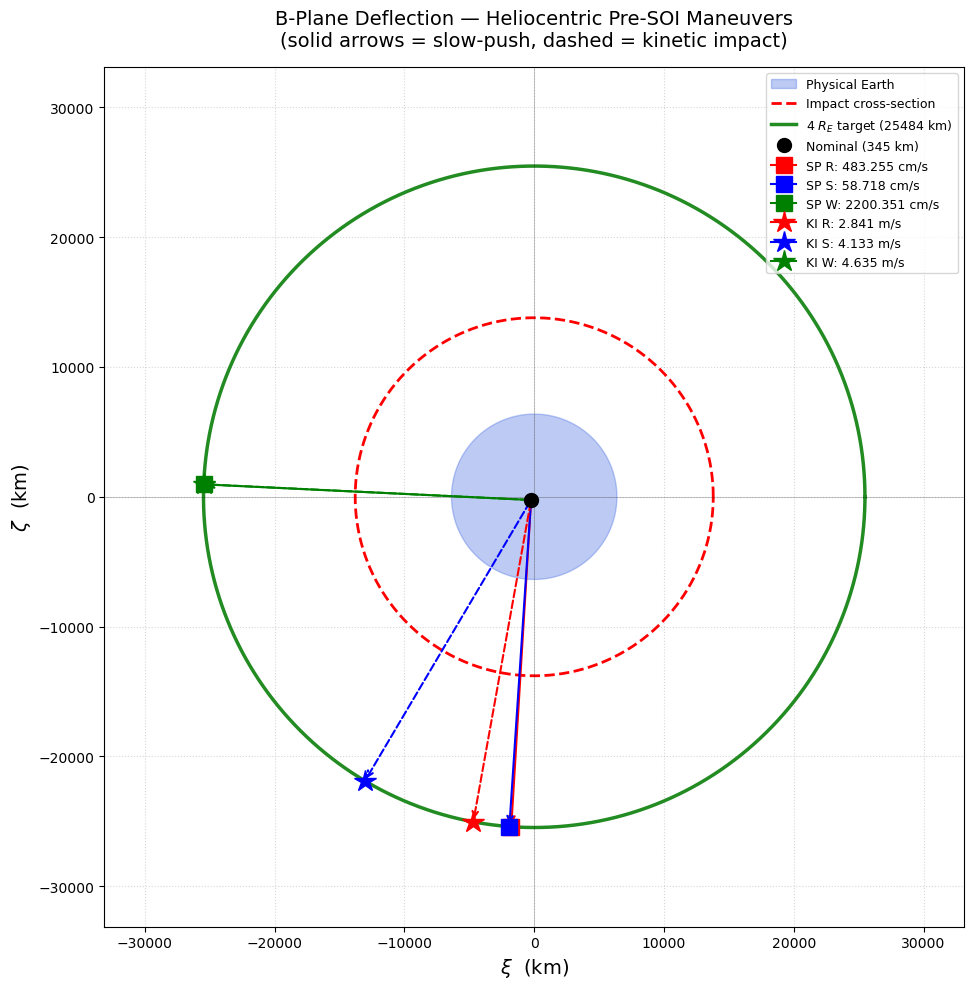

In [ ]:
"""
Heliocentric Deflection — Pre-SOI Maneuvers
============================================
Apply deflection from epoch (t = 0) through the heliocentric
approach phase, BEFORE the asteroid enters Earth's SOI.

Three scenarios:
  1. Continuous slow-push  (constant acceleration, epoch → SOI)
  2. Kinetic impact        (instantaneous ΔV at optimal time before SOI)
  3. Interactive tool       (user-specified heliocentric scenarios)

The RSW frame is heliocentric:
  R = radial from the Sun
  S = transverse in the heliocentric orbital plane
  W = normal to the heliocentric orbital plane
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import time as _clock

def _osculating_bplane(r, v, mu_val, v_planet):
    """Osculating Opik B-plane (xi, zeta, |B|) from geocentric state."""
    rm = np.linalg.norm(r)
    ev = np.cross(v, np.cross(r, v)) / mu_val - r / rm
    e_osc = np.linalg.norm(ev)
    hv = np.cross(r, v)
    hm = np.linalg.norm(hv)
    eps = 0.5 * np.linalg.norm(v)**2 - mu_val / rm
    if eps <= 0 or e_osc < 1:
        return 0., 0., np.inf
    a_osc = -mu_val / (2 * eps)
    vi = np.sqrt(-mu_val / a_osc)
    Phat = ev / e_osc
    Qhat = np.cross(hv / hm, Phat)
    S = Phat / e_osc + np.sqrt(e_osc**2 - 1) / e_osc * Qhat
    Bv = np.cross(S, hv) / vi
    xih = np.cross(v_planet, S)
    xih_n = np.linalg.norm(xih)
    if xih_n < 1e-30:
        return 0., 0., np.linalg.norm(Bv)
    xih /= xih_n
    zeh = -np.cross(S, xih)
    return np.dot(Bv, xih), np.dot(Bv, zeh), np.linalg.norm(Bv)


# ──────────────────────────────────────────────────────────────
#  1  HELIOCENTRIC PROPAGATOR  (RK4, two-stage time step)
# ──────────────────────────────────────────────────────────────

def _prop_helio(r0, v0, t0, a_R=0., a_S=0., a_W=0.,
                dt_coarse=3600., dt_fine=120.):
    """
    Propagate heliocentric two-body + constant RSW acceleration
    until the asteroid enters Earth's SOI.

    Returns (r_geo, v_geo, t_soi, v_earth) at SOI entry,
    or (None, None, None, None) if SOI is not reached.
    """
    r, v, t = np.array(r0, float), np.array(v0, float), float(t0)
    has_thr = (a_R != 0.) or (a_S != 0.) or (a_W != 0.)

    def acc(p, u):
        pm = np.linalg.norm(p)
        a = -GM_SUN * p / pm**3
        if has_thr:
            Rh = p / pm
            hv = np.cross(p, u)
            Wh = hv / np.linalg.norm(hv)
            Sh = np.cross(Wh, Rh)
            a = a + a_R * Rh + a_S * Sh + a_W * Wh
        return a

    def rk4(r, v, h):
        k1v = acc(r, v);                          k1r = v
        k2v = acc(r + .5*h*k1r, v + .5*h*k1v);   k2r = v + .5*h*k1v
        k3v = acc(r + .5*h*k2r, v + .5*h*k2v);   k3r = v + .5*h*k2v
        k4v = acc(r + h*k3r,    v + h*k3v);       k4r = v + h*k3v
        return (r + h/6*(k1r + 2*k2r + 2*k3r + k4r),
                v + h/6*(k1v + 2*k2v + 2*k3v + k4v))

    near = False
    t_end = t0 + 500 * 86400
    while t < t_end:
        dt = dt_fine if near else dt_coarse
        r, v = rk4(r, v, dt)
        t += dt
        re, ve = state_from_elements(earth_el, t)
        sep = np.linalg.norm(r - re)
        if sep < SOI:
            return r - re, v - ve, t, ve
        if sep < 2 * SOI:
            near = True
    return None, None, None, None


# ──────────────────────────────────────────────────────────────
#  2  VERIFY NOMINAL HELIOCENTRIC PROPAGATION
# ──────────────────────────────────────────────────────────────
r0_hl, v0_hl = state_from_elements(fi2026_el, 0.)
rg_hl, vg_hl, ts_hl, ve_hl = _prop_helio(r0_hl, v0_hl, 0.)
xi_hl, ze_hl, B_hl = _osculating_bplane(rg_hl, vg_hl, GM_EARTH, ve_hl)

print("=" * 60)
print("  Heliocentric Propagation — Nominal Verification")
print("=" * 60)
print(f"  SOI entry:  analytic = {t_soi/86400:.2f} d,  "
      f"numeric = {ts_hl/86400:.2f} d  "
      f"(Δ = {abs(ts_hl - t_soi)/3600:.1f} h)")
print(f"  |B|:  cell-0 = {B_mag/1e3:.1f} km,  "
      f"helio prop = {B_hl/1e3:.1f} km")
print(f"  (ξ, ζ): ({xi_B/1e3:.1f}, {zeta_B/1e3:.1f}) vs "
      f"({xi_hl/1e3:.1f}, {ze_hl/1e3:.1f}) km\n")


# ──────────────────────────────────────────────────────────────
#  3  SLOW-PUSH  (constant heliocentric RSW accel, epoch → SOI)
# ──────────────────────────────────────────────────────────────
B_tgt_hl = 4 * R_EARTH

def _B_helio_accel(a_mag, d):
    """Return |B| for constant heliocentric acceleration in direction d."""
    kw = {'a_R': 0., 'a_S': 0., 'a_W': 0.}
    kw[f'a_{d}'] = a_mag
    rg, vg, ts, ve = _prop_helio(r0_hl, v0_hl, 0., **kw)
    if rg is None:
        return 1e20
    _, _, B = _osculating_bplane(rg, vg, GM_EARTH, ve)
    return B

print("─" * 60)
print("  3. SLOW-PUSH  (heliocentric RSW, epoch → SOI)")
print("─" * 60 + "\n")

_t0_sp = _clock.time()
sp_hl = {}

for d in ['R', 'S', 'W']:
    print(f"  {d}-direction: solving...", end='', flush=True)

    Bp = _B_helio_accel(+1e-12, d)
    Bm = _B_helio_accel(-1e-12, d)
    sgn = 1.0 if Bp > Bm else -1.0

    lo, hi = 0., 1e-9
    for _ in range(30):
        Bhi = _B_helio_accel(sgn * hi, d)
        if Bhi >= B_tgt_hl or hi > 1:
            break
        hi *= 3

    if _B_helio_accel(sgn * hi, d) < B_tgt_hl:
        print(f" could not bracket — skipped")
        continue

    for _ in range(40):
        mid = .5 * (lo + hi)
        if _B_helio_accel(sgn * mid, d) < B_tgt_hl:
            lo = mid
        else:
            hi = mid
        if (hi - lo) / max(hi, 1e-30) < 1e-8:
            break

    a_f = .5 * (lo + hi)
    kw = {'a_R': 0., 'a_S': 0., 'a_W': 0.}
    kw[f'a_{d}'] = sgn * a_f
    rg, vg, ts, ve = _prop_helio(r0_hl, v0_hl, 0., **kw)
    xi_d, ze_d, B_d = _osculating_bplane(rg, vg, GM_EARTH, ve)
    dv_d = a_f * ts

    sp_hl[d] = dict(a=a_f, sgn=sgn, dv=dv_d, xi=xi_d, zeta=ze_d,
                    B=B_d, t_soi=ts)

    print(f" done")
    print(f"    Accel    = {a_f:.4e} m/s²  (sign {'+'if sgn>0 else '-'})")
    print(f"    Duration = {ts/86400:.1f} days")
    print(f"    ΔV       = {dv_d:.6f} m/s  ({dv_d*100:.4f} cm/s)")
    print(f"    |B|      = {B_d/1e3:.1f} km  ({B_d/R_EARTH:.2f} R_E)")
    print(f"    (ξ, ζ)   = ({xi_d/1e3:+.1f}, {ze_d/1e3:+.1f}) km\n")

if sp_hl:
    best_sp_hl = min(sp_hl, key=lambda d: sp_hl[d]['dv'])
    print(f"  ⇒ Best: {best_sp_hl}-direction,  "
          f"ΔV = {sp_hl[best_sp_hl]['dv']*100:.4f} cm/s")
print(f"    (took {_clock.time() - _t0_sp:.1f} s)\n")


# ──────────────────────────────────────────────────────────────
#  4  KINETIC IMPACT  (instantaneous ΔV at optimal helio time)
# ──────────────────────────────────────────────────────────────

def _ki_helio(dv_mag, d, t_imp):
    """Apply heliocentric RSW impulse at t_imp, return (ξ, ζ, |B|)."""
    r_i, v_i = state_from_elements(fi2026_el, t_imp)
    rm = np.linalg.norm(r_i)
    Rh = r_i / rm
    hv = np.cross(r_i, v_i)
    Wh = hv / np.linalg.norm(hv)
    Sh = np.cross(Wh, Rh)
    dvec = {'R': Rh, 'S': Sh, 'W': Wh}[d]
    v_new = v_i + dv_mag * dvec
    rg, vg, ts, ve = _prop_helio(r_i, v_new, t_imp)
    if rg is None:
        return 0., 0., 1e20
    return _osculating_bplane(rg, vg, GM_EARTH, ve)

print("─" * 60)
print("  4. KINETIC IMPACT  (heliocentric RSW, single impulse)")
print("─" * 60 + "\n")

_t0_ki = _clock.time()

N_ki = 12
t_cands_hl = np.linspace(1 * 86400, ts_hl - 1 * 86400, N_ki)

ki_hl = {}

for d in ['R', 'S', 'W']:
    print(f"  {d}-direction: scanning {N_ki} impulse times...",
          end='', flush=True)

    # Phase 1 — linear sensitivity at each candidate
    eps_h = 0.1
    sens_h = np.zeros(N_ki)
    dv_est_h = np.full(N_ki, np.inf)

    for j, t_imp in enumerate(t_cands_hl):
        _, _, Bp = _ki_helio(+eps_h, d, t_imp)
        _, _, Bm = _ki_helio(-eps_h, d, t_imp)
        s = (Bp - Bm) / (2 * eps_h)
        sens_h[j] = s
        if abs(s) > 1e-20:
            dv_est_h[j] = abs((B_tgt_hl - B_hl) / s)

    j_best = int(np.argmin(dv_est_h))
    t_best = t_cands_hl[j_best]
    sgn_ki = 1.0 if sens_h[j_best] > 0 else -1.0

    print(f" best ≈ t = {t_best/86400:.0f} d", flush=True)

    # Phase 2 — nonlinear bisection at best candidate
    lo, hi = 0., max(1., dv_est_h[j_best]) * 5
    _, _, Bhi = _ki_helio(sgn_ki * hi, d, t_best)
    for _ in range(15):
        if Bhi >= B_tgt_hl or hi > 1e5:
            break
        hi *= 3
        _, _, Bhi = _ki_helio(sgn_ki * hi, d, t_best)

    if Bhi < B_tgt_hl:
        sgn_ki *= -1
        hi = max(1., dv_est_h[j_best]) * 5
        _, _, Bhi = _ki_helio(sgn_ki * hi, d, t_best)
        for _ in range(15):
            if Bhi >= B_tgt_hl or hi > 1e5:
                break
            hi *= 3
            _, _, Bhi = _ki_helio(sgn_ki * hi, d, t_best)

    if Bhi < B_tgt_hl:
        print(f"    could not bracket — skipped\n")
        continue

    for _ in range(40):
        mid = .5 * (lo + hi)
        _, _, Bmid = _ki_helio(sgn_ki * mid, d, t_best)
        if Bmid < B_tgt_hl:
            lo = mid
        else:
            hi = mid
        if (hi - lo) / max(hi, 1e-30) < 1e-8:
            break

    dv_f = .5 * (lo + hi)
    xi_f, ze_f, B_f = _ki_helio(sgn_ki * dv_f, d, t_best)

    ki_hl[d] = dict(abs_dv=dv_f, dv=sgn_ki * dv_f, t_imp=t_best,
                    xi=xi_f, zeta=ze_f, B=B_f,
                    sens=sens_h.copy(), dv_est=dv_est_h.copy(),
                    t_cands=t_cands_hl.copy())

    print(f"    ΔV       = {dv_f:.4f} m/s  ({dv_f*100:.2f} cm/s)")
    print(f"    Impulse  = {t_best/86400:.1f} days after epoch")
    print(f"    |B|      = {B_f/1e3:.1f} km  ({B_f/R_EARTH:.2f} R_E)\n")

if ki_hl:
    best_ki_hl = min(ki_hl, key=lambda d: ki_hl[d]['abs_dv'])
    rki_hl = ki_hl[best_ki_hl]
    print(f"  ⇒ Best: {best_ki_hl}-direction,  "
          f"ΔV = {rki_hl['abs_dv']:.4f} m/s  "
          f"at t = {rki_hl['t_imp']/86400:.0f} d")
print(f"    (took {_clock.time() - _t0_ki:.1f} s)\n")


# ──────────────────────────────────────────────────────────────
#  5  B-PLANE VISUALIZATION  (all heliocentric results)
# ──────────────────────────────────────────────────────────────
fig_hl, ax_hl = plt.subplots(figsize=(10, 10))
th_hl = np.linspace(0, 2 * np.pi, 500)

ax_hl.fill(R_EARTH/1e3 * np.cos(th_hl), R_EARTH/1e3 * np.sin(th_hl),
           color='royalblue', alpha=0.35, label='Physical Earth')
ax_hl.plot(B_impact/1e3 * np.cos(th_hl), B_impact/1e3 * np.sin(th_hl),
           'r--', lw=2, label='Impact cross-section')
ax_hl.plot(B_tgt_hl/1e3 * np.cos(th_hl), B_tgt_hl/1e3 * np.sin(th_hl),
           color='forestgreen', ls='-', lw=2.5,
           label=f'4 $R_E$ target ({B_tgt_hl/1e3:.0f} km)')
ax_hl.plot(xi_hl/1e3, ze_hl/1e3, 'ko', ms=10, zorder=5,
           label=f'Nominal ({B_hl/1e3:.0f} km)')

clrs_hl = {'R': 'red', 'S': 'blue', 'W': 'green'}

for d in sp_hl:
    r = sp_hl[d]
    ax_hl.plot(r['xi']/1e3, r['zeta']/1e3,
               color=clrs_hl[d], marker='s', ms=12, zorder=5,
               label=f'SP {d}: {r["dv"]*100:.3f} cm/s')
    ax_hl.annotate('', xy=(r['xi']/1e3, r['zeta']/1e3),
                   xytext=(xi_hl/1e3, ze_hl/1e3),
                   arrowprops=dict(arrowstyle='->', color=clrs_hl[d],
                                   lw=1.5, ls='-'))

for d in ki_hl:
    r = ki_hl[d]
    ax_hl.plot(r['xi']/1e3, r['zeta']/1e3,
               color=clrs_hl[d], marker='*', ms=16, zorder=5,
               label=f'KI {d}: {r["abs_dv"]:.3f} m/s')
    ax_hl.annotate('', xy=(r['xi']/1e3, r['zeta']/1e3),
                   xytext=(xi_hl/1e3, ze_hl/1e3),
                   arrowprops=dict(arrowstyle='->', color=clrs_hl[d],
                                   lw=1.5, ls='--'))

all_B_hl = ([B_tgt_hl]
            + [sp_hl[d]['B'] for d in sp_hl]
            + [ki_hl[d]['B'] for d in ki_hl])
lim_hl = max(all_B_hl) / 1e3 * 1.3
ax_hl.set_xlim(-lim_hl, lim_hl)
ax_hl.set_ylim(-lim_hl, lim_hl)
ax_hl.set_aspect('equal')
ax_hl.axhline(0, c='k', lw=0.5, alpha=0.3)
ax_hl.axvline(0, c='k', lw=0.5, alpha=0.3)
ax_hl.grid(True, ls=':', alpha=0.5)
ax_hl.set_xlabel(r'$\xi$  (km)', fontsize=14)
ax_hl.set_ylabel(r'$\zeta$  (km)', fontsize=14)
ax_hl.set_title('B-Plane Deflection — Heliocentric Pre-SOI Maneuvers\n'
                '(solid arrows = slow-push, dashed = kinetic impact)',
                fontsize=14, pad=15)
ax_hl.legend(fontsize=9, loc='upper right')
plt.tight_layout()
plt.show()



# ──────────────────────────────────────────────────────────────
#  6  INTERACTIVE TOOL  (custom heliocentric scenarios)
# ──────────────────────────────────────────────────────────────

def run_helio_deflection(mode='slow_push',
                         a_R=0., a_S=0., a_W=0.,
                         dv_R=0., dv_S=0., dv_W=0.,
                         impulse_days=None,
                         show_plot=True):
    """
    Heliocentric deflection tool.

    Parameters
    ----------
    mode : str
        'slow_push'      — constant acceleration from epoch to SOI.
        'kinetic_impact'  — instantaneous ΔV at impulse_days.

    a_R, a_S, a_W : float   (slow_push mode)
        Constant accelerations in HELIOCENTRIC RSW frame [m/s²].

    dv_R, dv_S, dv_W : float   (kinetic_impact mode)
        Instantaneous ΔV components in HELIOCENTRIC RSW frame [m/s].

    impulse_days : float   (kinetic_impact mode)
        Time of impulse [days after epoch].  Default = 1 day.

    show_plot : bool
        Show b-plane visualization.

    Returns
    -------
    dict with keys: xi, zeta, B, t_soi, dv_total
    """
    if mode == 'slow_push':
        rg, vg, ts, ve = _prop_helio(r0_hl, v0_hl, 0.,
                                     a_R=a_R, a_S=a_S, a_W=a_W)
        if rg is None:
            print("  Asteroid did not reach SOI — deflection too large!")
            return None
        xi_c, ze_c, B_c = _osculating_bplane(rg, vg, GM_EARTH, ve)
        dv_t = np.sqrt((a_R * ts)**2 + (a_S * ts)**2 + (a_W * ts)**2)

        print("=" * 60)
        print("  HELIOCENTRIC SLOW-PUSH  (custom)")
        print("=" * 60)
        print(f"  (a_R, a_S, a_W) = ({a_R:.3e}, {a_S:.3e}, {a_W:.3e}) m/s²")
        print(f"  Thrust duration  = {ts/86400:.1f} days")
        print(f"  Total ΔV         = {dv_t:.6f} m/s  ({dv_t*100:.4f} cm/s)")
        print(f"  |B|              = {B_c/1e3:.1f} km  ({B_c/R_EARTH:.2f} R_E)")
        print(f"  (ξ, ζ)           = ({xi_c/1e3:+.1f}, {ze_c/1e3:+.1f}) km")
        print("=" * 60)

    elif mode == 'kinetic_impact':
        t_imp = (impulse_days if impulse_days is not None else 1.) * 86400.
        r_i, v_i = state_from_elements(fi2026_el, t_imp)
        rm = np.linalg.norm(r_i)
        Rh = r_i / rm
        hv = np.cross(r_i, v_i)
        Wh = hv / np.linalg.norm(hv)
        Sh = np.cross(Wh, Rh)
        v_new = v_i + dv_R * Rh + dv_S * Sh + dv_W * Wh

        rg, vg, ts, ve = _prop_helio(r_i, v_new, t_imp)
        if rg is None:
            print("  Asteroid did not reach SOI — deflection too large!")
            return None
        xi_c, ze_c, B_c = _osculating_bplane(rg, vg, GM_EARTH, ve)
        dv_t = np.sqrt(dv_R**2 + dv_S**2 + dv_W**2)

        print("=" * 60)
        print("  HELIOCENTRIC KINETIC IMPACT  (custom)")
        print("=" * 60)
        print(f"  (ΔV_R, ΔV_S, ΔV_W) = ({dv_R:.4f}, {dv_S:.4f}, "
              f"{dv_W:.4f}) m/s")
        print(f"  Impulse at          = {t_imp/86400:.1f} days after epoch")
        print(f"  |ΔV|                = {dv_t:.4f} m/s  ({dv_t*100:.2f} cm/s)")
        print(f"  |B|                 = {B_c/1e3:.1f} km  "
              f"({B_c/R_EARTH:.2f} R_E)")
        print(f"  (ξ, ζ)              = ({xi_c/1e3:+.1f}, "
              f"{ze_c/1e3:+.1f}) km")
        print("=" * 60)

    else:
        raise ValueError(f"Unknown mode '{mode}'. "
                         f"Use 'slow_push' or 'kinetic_impact'.")

    if show_plot:
        fig, ax = plt.subplots(figsize=(8, 8))
        th = np.linspace(0, 2 * np.pi, 400)
        ax.add_patch(patches.Circle((0, 0), R_EARTH/1e3,
                     color='royalblue', alpha=0.4, label='Earth'))
        ax.plot(B_impact/1e3 * np.cos(th), B_impact/1e3 * np.sin(th),
                'r--', lw=2, label='Impact cross-section')
        ax.plot(B_tgt_hl/1e3 * np.cos(th), B_tgt_hl/1e3 * np.sin(th),
                color='forestgreen', lw=2, label=r'4 $R_E$')
        ax.plot(xi_hl/1e3, ze_hl/1e3, 'ko', ms=8, label='Nominal')
        ax.plot(xi_c/1e3, ze_c/1e3, 'm*', ms=16,
                label=f'Custom ({B_c/1e3:.0f} km)')
        lim = max(B_tgt_hl, B_c) / 1e3 * 1.3
        ax.set_xlim(-lim, lim)
        ax.set_ylim(-lim, lim)
        ax.set_aspect('equal')
        ax.grid(True, ls=':', alpha=0.6)
        ax.set_xlabel(r'$\xi$ (km)', fontsize=13)
        ax.set_ylabel(r'$\zeta$ (km)', fontsize=13)
        ax.set_title(f'B-plane — Heliocentric '
                     f'{mode.replace("_", " ").title()}', fontsize=14)
        ax.legend(fontsize=10)
        plt.tight_layout()
        plt.show()

    return dict(xi=xi_c, zeta=ze_c, B=B_c, t_soi=ts, dv_total=dv_t)

# Example usage (uncomment to test):
# run_helio_deflection('slow_push', a_S=1e-10)
# run_helio_deflection('kinetic_impact', dv_S=0.05, impulse_days=50)


  Valsecchi Circle Parameters
  v_Earth         = 29.6947 km/s
  v_∞ (encounter) = 5.8244 km/s
  U_V             = 0.196141  (dimensionless)
  a_FI2026        = 0.918904 AU
  cos θ           = -0.323044
  sin θ           = 0.946384  (> 0 req. for Opik)
  c               = 11750.1 km  (1.844 R_E)

  Accessible a' range: [0.699, 1.548] AU

  Resonances with visible circles (20 found):
     k:h    a' (AU)      D (km)      R (km)     cos th'
  5: 6         0.8855     -106421      101655    -0.42754
  4: 5         0.8618      -60465       55072    -0.50695
  1: 1         1.0000      +49429       51977    -0.09807
  7: 9         0.8457      -46336       40463    -0.56303
  3: 4         0.8255      -35419       28850    -0.63700
  9: 8         1.0817      +26636       28019     0.09444
  8: 7         1.0931      +25153       26389     0.11905
  7: 6         1.1082      +23463       24509     0.15089
  6: 5         1.1292      +21520       22309     0.19369
  5: 4         1.1604      +19261   

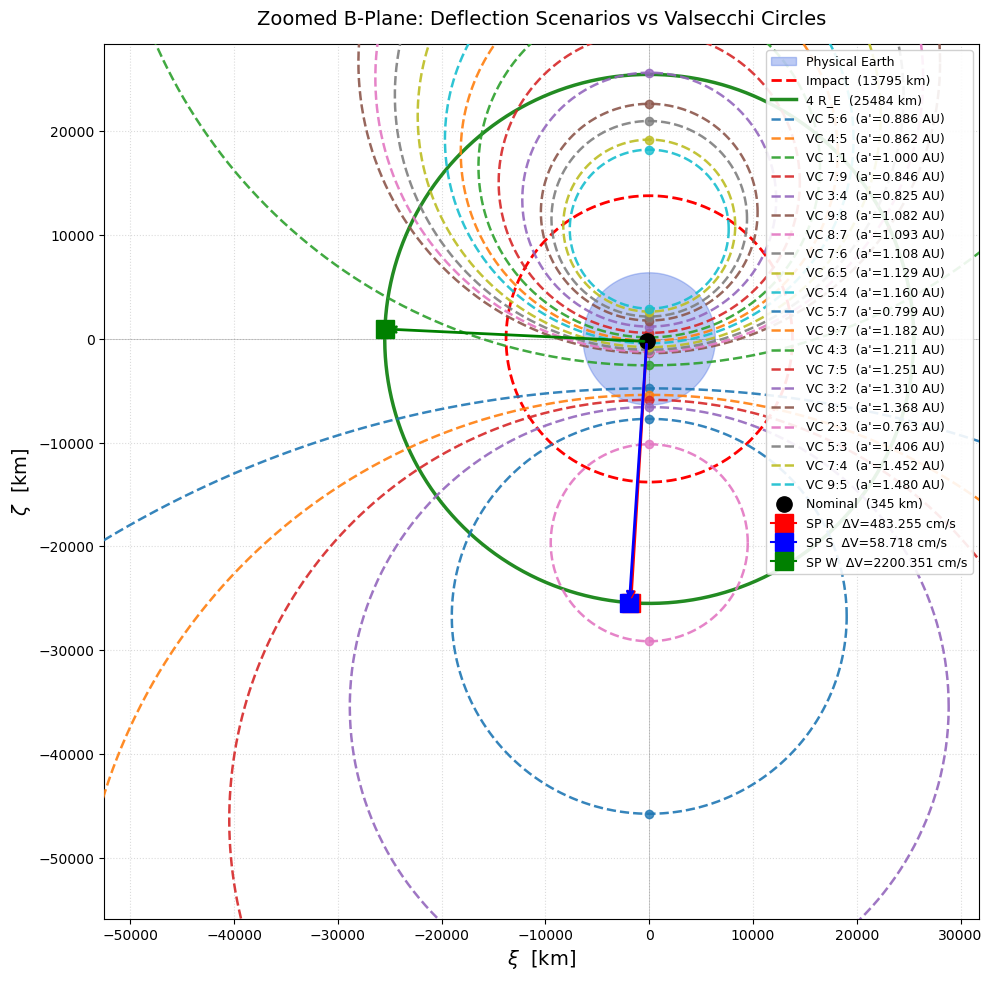

In [ ]:
"""
Valsecchi Circles on the FI2026 Optimal B-Plane

For a k/h resonance (h asteroid revolutions = k Earth revolutions)
the post-encounter semi-major axis is

    a'_0 = (k/h)^(2/3)  [AU]

which sets the post-encounter angle via energy conservation
(Opik formulation, planet on unit-radius circular orbit):

    cos θ'_0 = (1 - U_V² - 1/a'_0) / (2 U_V)

All pre-encounter b-plane points (ξ, ζ) that lead to this resonant
return lie on the VALSECCHI CIRCLE (Eq. 8):

    ξ² + (ζ − D)² = R²

with centre D (on the ζ-axis) and radius R:

    D = c · sin θ / (cos θ'_0 − cos θ)
    R = |c · sin θ'_0 / (cos θ'_0 − cos θ)|

where  c = GM_Earth / v_∞²  [m]
and  U_V = v_∞ / v_Earth  (dimensionless Opik speed).

These circles are drawn in the same (ξ, ζ) frame as the Farnocchia
b-plane used throughout this notebook.
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ──────────────────────────────────────────────────────────────
#  1  OPIK PARAMETERS FOR FI2026 ENCOUNTER
# ──────────────────────────────────────────────────────────────
v_Earth_mag = np.linalg.norm(v_pl)          # ||v_Earth||  [m/s]
U_V  = v_inf / v_Earth_mag                  # dimensionless Opik speed

# Semi-major axis of FI2026 heliocentric orbit [AU]
a_fi_AU = (fi2026_el['q'] / (1 - fi2026_el['e'])) / AU

# Pre-encounter angle θ  (Opik, Eq. derived from heliocentric energy at r=1)
# cos θ = (1 - U_V² - 1/a) / (2 U_V)
cos_theta = (1.0 - U_V**2 - 1.0/a_fi_AU) / (2.0 * U_V)
cos_theta = np.clip(cos_theta, -1, 1)
sin_theta = np.sqrt(1.0 - cos_theta**2)

# Characteristic length  c = GM_Earth / v_inf²  [m]
c_val = GM_EARTH / v_inf**2

print("=" * 60)
print("  Valsecchi Circle Parameters")
print("=" * 60)
print(f"  v_Earth         = {v_Earth_mag/1e3:.4f} km/s")
print(f"  v_∞ (encounter) = {v_inf/1e3:.4f} km/s")
print(f"  U_V             = {U_V:.6f}  (dimensionless)")
print(f"  a_FI2026        = {a_fi_AU:.6f} AU")
print(f"  cos θ           = {cos_theta:.6f}")
print(f"  sin θ           = {sin_theta:.6f}  (> 0 req. for Opik)")
print(f"  c               = {c_val/1e3:.1f} km  ({c_val/R_EARTH:.3f} R_E)")
print()

# ──────────────────────────────────────────────────────────────
#  2  COMPUTE VALSECCHI CIRCLES
# ──────────────────────────────────────────────────────────────
# Resonance k/h: h asteroid rev. = k Earth rev.  →  a' = (k/h)^(2/3) AU
# Accessible range: |cos θ'_0| ≤ 1  →  a' ∈ [1/(1+U_V)², 1/(1-U_V)²] AU
a_min_acc = 1.0 / (1.0 + U_V)**2
a_max_acc = 1.0 / (1.0 - U_V)**2
print(f"  Accessible a' range: [{a_min_acc:.3f}, {a_max_acc:.3f}] AU\n")

# Plot scale: use the nominal B and 4-RE target to set a sensible limit
_plot_lim_m = max(B_impact * 1.5, 4 * R_EARTH * 1.4)

def valsecchi_circle(k, h):
    """
    Compute centre (0, D) and radius R of the Valsecchi circle
    for resonance k:h (k Earth years = h asteroid revolutions).

    Returns (D_km, R_km, label, cos_theta_prime) or None if inaccessible.
    """
    a_prime = (k / h) ** (2.0 / 3.0)          # AU
    if not (a_min_acc <= a_prime <= a_max_acc):
        return None
    # skip if a_prime ≈ a_fi (circle degenerates to a line)
    if abs(a_prime - a_fi_AU) < 0.002:
        return None
    cos_th_p = (1.0 - U_V**2 - 1.0/a_prime) / (2.0 * U_V)
    if abs(cos_th_p) > 1.0:
        return None
    sin_th_p  = np.sqrt(1.0 - cos_th_p**2)
    dcos      = cos_th_p - cos_theta
    if abs(dcos) < 1e-12:
        return None
    D = c_val * sin_theta / dcos
    R = abs(c_val * sin_th_p / dcos)
    return D, R, k, h, a_prime, cos_th_p

# Candidate resonances: k and h from 1 to 9
resonances = []
for h in range(1, 10):
    for k in range(1, 10):
        result = valsecchi_circle(k, h)
        if result is None:
            continue
        D, R, k_, h_, a_prime, cos_th_p = result
        # Only include circles that intersect or are close to our plot region
        if R < _plot_lim_m * 3 and abs(D) < _plot_lim_m * 5:
            resonances.append((k_, h_, a_prime, D, R, cos_th_p))

# Sort by radius (descending) and de-duplicate near-identical circles
resonances.sort(key=lambda x: -x[4])
deduped = []
seen = set()
for entry in resonances:
    k_, h_, a_p, D, R, ctp = entry
    # Reduce fraction
    from math import gcd
    g = gcd(k_, h_)
    key = (k_//g, h_//g)
    if key not in seen:
        seen.add(key)
        deduped.append(entry)

print(f"  Resonances with visible circles ({len(deduped)} found):")
_h1, _h2, _h3, _h4, _h5 = "k:h", "a' (AU)", "D (km)", "R (km)", "cos th'"
print(f"  {_h1:>6}  {_h2:>9}  {_h3:>10}  {_h4:>10}  {_h5:>10}")
for k_, h_, a_p, D, R, ctp in deduped:
    g = gcd(k_, h_)
    print(f"  {k_//g}:{h_//g:>2}      {a_p:>9.4f}  {D/1e3:>+10.0f}  "
          f"{R/1e3:>10.0f}  {ctp:>10.5f}")

# ──────────────────────────────────────────────────────────────
#  3  COLOUR CYCLE  (used by zoomed plot)
# ──────────────────────────────────────────────────────────────
_cmap = plt.get_cmap('tab10')
_colors = [_cmap(i % 10) for i in range(len(deduped))]
th_c = np.linspace(0, 2 * np.pi, 600)

# ──────────────────────────────────────────────────────────────
#  4  ZOOMED-IN VIEW  (around the nominal and deflected points)
# ──────────────────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(10, 10))

# Build zoom limit from the spread of deflected points
_pts_km = [np.array([xi_hl/1e3, ze_hl/1e3])]
for _r in list(sp_hl.values()) + list(ki_hl.values()):
    _pts_km.append(np.array([_r['xi']/1e3, _r['zeta']/1e3]))
_pts_km = np.array(_pts_km)
_ctr = _pts_km.mean(axis=0)
_span = max(np.linalg.norm(_pts_km - _ctr, axis=1).max() * 2,
            4 * R_EARTH / 1e3 * 1.4)

ax2.fill(R_EARTH/1e3 * np.cos(th_c), R_EARTH/1e3 * np.sin(th_c),
         color='royalblue', alpha=0.35, zorder=2,
         label='Physical Earth')
ax2.plot(B_impact/1e3 * np.cos(th_c), B_impact/1e3 * np.sin(th_c),
         'r--', lw=2, zorder=3,
         label=f'Impact  ({B_impact/1e3:.0f} km)')
ax2.plot(4*R_EARTH/1e3 * np.cos(th_c), 4*R_EARTH/1e3 * np.sin(th_c),
         color='forestgreen', ls='-', lw=2.5, zorder=3,
         label=f'4 R_E  ({4*R_EARTH/1e3:.0f} km)')

for i, (k_, h_, a_p, D, R, ctp) in enumerate(deduped):
    from math import gcd
    g = gcd(k_, h_)
    xc = R/1e3 * np.cos(th_c)
    yc = D/1e3 + R/1e3 * np.sin(th_c)
    # Only draw arcs that pass through the zoomed window
    xmin2, xmax2 = _ctr[0] - _span, _ctr[0] + _span
    ymin2, ymax2 = _ctr[1] - _span, _ctr[1] + _span
    in_view = ((xc > xmin2) & (xc < xmax2) &
               (yc > ymin2) & (yc < ymax2))
    if in_view.any():
        ax2.plot(xc, yc, color=_colors[i], lw=1.8, ls='--', alpha=0.9,
                 zorder=4, label=f'VC {k_//g}:{h_//g}  (a\'={a_p:.3f} AU)')
        for dpm in [+1, -1]:
            zi = (D + dpm * R) / 1e3
            if ymin2 < zi < ymax2:
                ax2.plot(0, zi, 'o', color=_colors[i], ms=6,
                         zorder=5, alpha=0.8)

ax2.plot(xi_hl/1e3, ze_hl/1e3, 'ko', ms=11, zorder=7,
         label=f'Nominal  ({B_hl/1e3:.0f} km)')

for _d_sp, _r_sp in sp_hl.items():
    ax2.plot(_r_sp['xi']/1e3, _r_sp['zeta']/1e3,
             color=clrs_hl[_d_sp], marker='s', ms=13, zorder=7,
             label=f'SP {_d_sp}  ΔV={_r_sp["dv"]*100:.3f} cm/s')
    ax2.annotate('', xy=(_r_sp['xi']/1e3, _r_sp['zeta']/1e3),
                 xytext=(xi_hl/1e3, ze_hl/1e3),
                 arrowprops=dict(arrowstyle='->', color=clrs_hl[_d_sp], lw=2),
                 zorder=8)

try:
    for d_ki, r_ki in ki_results.items():
        ax2.plot(r_ki['xi']/1e3, r_ki['zeta']/1e3,
                 color=_clrs_ki.get(d_ki, 'gray'), marker='D', ms=13,
                 zorder=7,
                 label=f'KI ({d_ki})  ΔV={r_ki["abs_dv"]:.3f} m/s')
        ax2.annotate('', xy=(r_ki['xi']/1e3, r_ki['zeta']/1e3),
                     xytext=(xi_hl/1e3, ze_hl/1e3),
                     arrowprops=dict(arrowstyle='->', lw=2,
                                    color=_clrs_ki.get(d_ki, 'gray')),
                     zorder=8)
except NameError:
    pass

ax2.set_xlim(_ctr[0] - _span, _ctr[0] + _span)
ax2.set_ylim(_ctr[1] - _span, _ctr[1] + _span)
ax2.set_aspect('equal')
ax2.axhline(0, c='k', lw=0.5, alpha=0.25)
ax2.axvline(0, c='k', lw=0.5, alpha=0.25)
ax2.grid(True, ls=':', alpha=0.45)
ax2.set_xlabel(r'$\xi$  [km]', fontsize=14)
ax2.set_ylabel(r'$\zeta$  [km]', fontsize=14)
ax2.set_title('Zoomed B-Plane: Deflection Scenarios vs Valsecchi Circles',
              fontsize=14, pad=14)
ax2.legend(fontsize=9, loc='upper right', framealpha=0.9)
plt.tight_layout()
plt.show()

  HELIOCENTRIC SLOW-PUSH  (custom)
  (a_R, a_S, a_W) = (0.000e+00, 0.000e+00, -1.897e-08) m/s²
  Thrust duration  = 358.2 days
  Total ΔV         = 0.587165 m/s  (58.7165 cm/s)
  |B|              = 938.2 km  (0.15 R_E)
  (ξ, ζ)           = (-913.5, -214.1) km


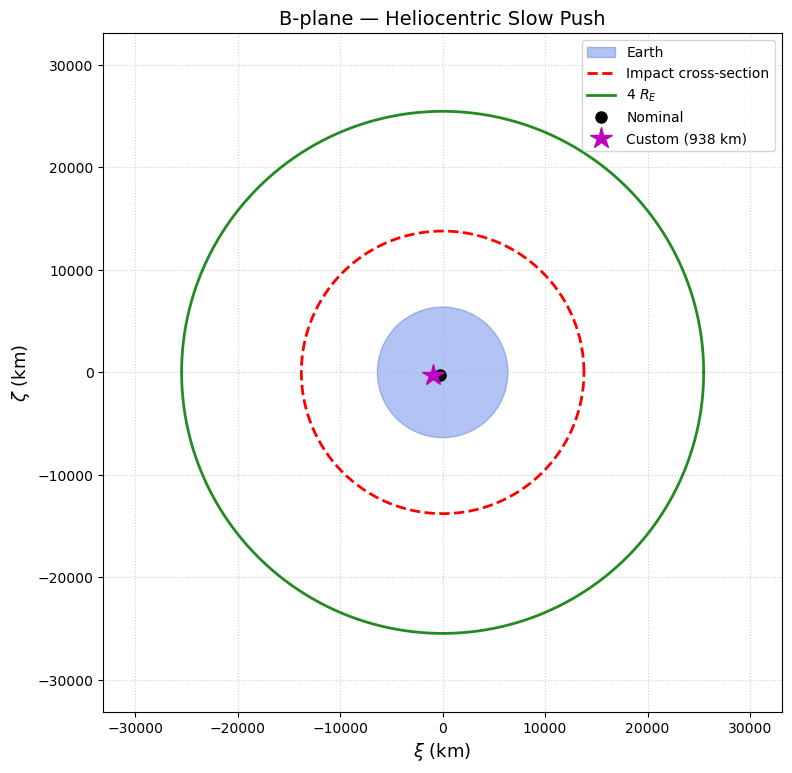

{'xi': np.float64(-913498.4222917901),
 'zeta': np.float64(-214061.72544661653),
 'B': np.float64(938243.9926963414),
 't_soi': 30947400.0,
 'dv_total': np.float64(0.5871650202)}

In [14]:
run_helio_deflection('slow_push', a_W=-1.8973e-08)

  HELIOCENTRIC KINETIC IMPACT  (custom)
  (ΔV_R, ΔV_S, ΔV_W) = (0.0000, 0.0000, 0.4159) m/s
  Impulse at          = 0.0 days after epoch
  |ΔV|                = 0.4159 m/s  (41.59 cm/s)
  |B|                 = 1051.9 km  (0.17 R_E)
  (ξ, ζ)              = (+1006.3, -306.4) km


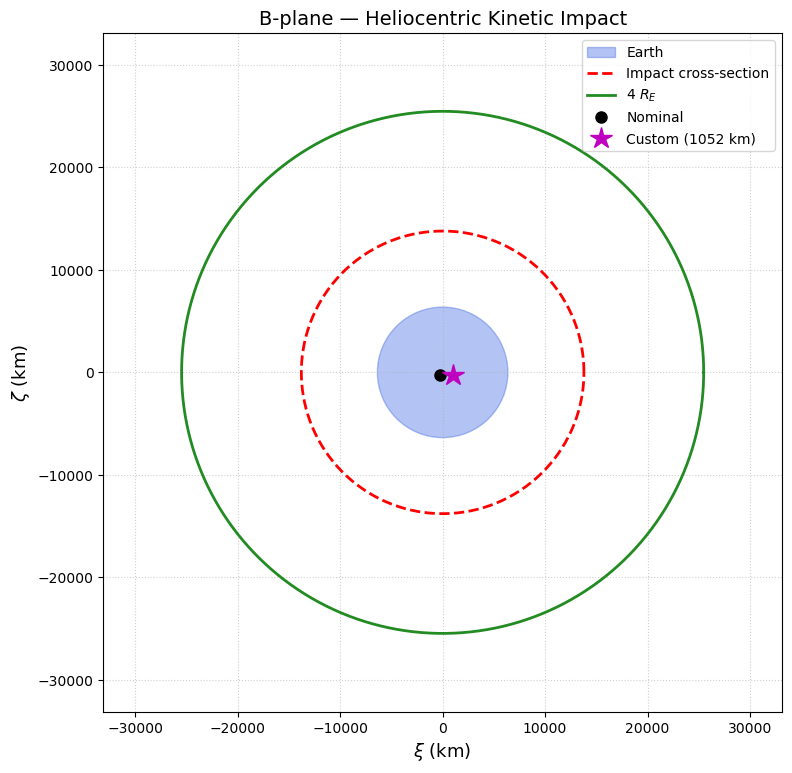

{'xi': np.float64(1006254.2981170649),
 'zeta': np.float64(-306392.9140796283),
 'B': np.float64(1051867.0687293492),
 't_soi': 30947280.0,
 'dv_total': np.float64(0.4159)}

In [16]:
run_helio_deflection('kinetic_impact', dv_W=0.4159, impulse_days=0)